# 01 - EDA y Limpieza (version simple)
## Produccion de Pozos No Convencionales (Vaca Muerta / YPF)

En este notebook vamos a:
1. Cargar los datos
2. Mirar que problemas tiene el dataset (nulos, valores raros)
3. Ver graficos para entender mejor esos problemas
4. Limpiar los datos usando las funciones de `preprocessor.py`
5. Volver a mirar los graficos para confirmar que la limpieza funciono

In [1]:
import sys
import os

sys.path.append("..")  # para poder importar los archivos que estan en src/

# Jupyter arranca parado en la carpeta "notebooks/", pero data_loader.py
# busca el archivo con la ruta "data/raw/...", que es relativa a la RAIZ
# del proyecto. Por eso nos paramos en la raiz antes de seguir.
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Carpeta de trabajo actual:", os.getcwd())

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import cargar_datos, mostrar_resumen
from src.preprocessor import limpiar_datos

sns.set_theme(style="whitegrid")
%matplotlib inline

Carpeta de trabajo actual: /Users/cristianaguilera/Desktop/proyecto-final-data-science


## Paso 1: Cargar los datos crudos (sin limpiar)

In [2]:
df = cargar_datos()
df.head()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [3]:
# Esta funcion nos muestra por consola un resumen de los problemas del dataset
mostrar_resumen(df)

Cantidad de filas y columnas: (421046, 40)

Columnas con valores nulos (vacios):
vida_util           412082
tipoextraccion         614
tipoestado             614
tipopozo               614
observaciones       397045
clasificacion          922
subclasificacion       922
sub_tipo_recurso       452
dtype: int64

Cuantos pozos repetidos hay (mismo pozo, mismo mes, mismo anio):
0

Valor maximo y minimo de profundidad:
Maximo: 378939.0
Minimo: 0.0

Cuantos pozos tienen produccion negativa (no deberia pasar):
Petroleo: 1
Gas: 2


## Paso 2: Graficos para entender los problemas

### 2.1 Cuantos nulos tiene cada columna

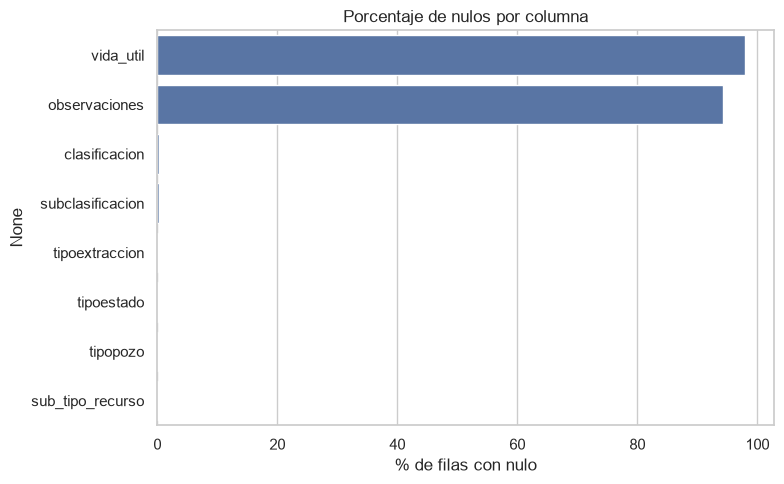

In [4]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, color="#4C72B0")
plt.xlabel("% de filas con nulo")
plt.title("Porcentaje de nulos por columna")
plt.tight_layout()
plt.show()

### 2.2 La profundidad tiene valores raros

Ya sabemos que hay un valor maximo de 378.939 (imposible para un pozo real).

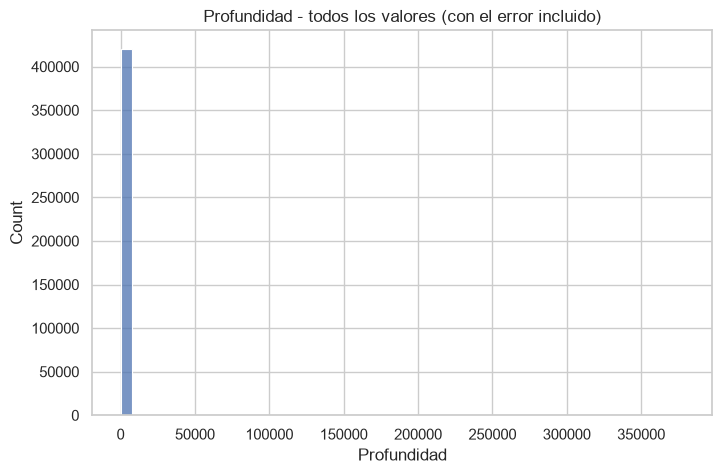

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["profundidad"].dropna(), bins=50, color="#4C72B0")
plt.title("Profundidad - todos los valores (con el error incluido)")
plt.xlabel("Profundidad")
plt.show()

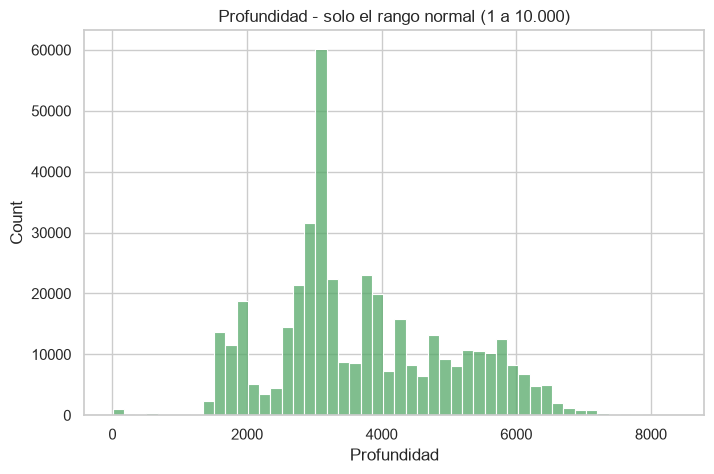

In [6]:
# Miramos solo los valores dentro de un rango normal para un pozo (1 a 10.000)
rango_normal = df[df["profundidad"].between(1, 10000)]["profundidad"]

plt.figure(figsize=(8, 5))
sns.histplot(rango_normal, bins=50, color="#55A868")
plt.title("Profundidad - solo el rango normal (1 a 10.000)")
plt.xlabel("Profundidad")
plt.show()

In [7]:
# Buscamos cuales son los pozos con profundidad mayor a 10.000
pozos_raros = df[df["profundidad"] > 10000]
print("Cantidad de filas raras:", len(pozos_raros))
print("Cantidad de pozos distintos:", pozos_raros["idpozo"].nunique())

pozos_raros[["idpozo", "anio", "mes", "profundidad", "formacion"]].head(10)

Cantidad de filas raras: 122
Cantidad de pozos distintos: 1


,idpozo,anio,mes,profundidad,formacion
337,156804,2018,1,378939.0,lajas
560,156804,2017,1,378939.0,lajas
822,156804,2018,2,378939.0,lajas
1246,156804,2017,2,378939.0,lajas
1440,156804,2017,3,378939.0,lajas
1509,156804,2018,3,378939.0,lajas
2445,156804,2018,4,378939.0,lajas
2648,156804,2017,4,378939.0,lajas
3003,156804,2018,5,378939.0,lajas
3329,156804,2017,5,378939.0,lajas


In [8]:
# Ahora buscamos los que tienen profundidad = 0 (tampoco tiene sentido)
pozos_en_cero = df[df["profundidad"] == 0]
print("Cantidad de filas en cero:", len(pozos_en_cero))
print("Cantidad de pozos distintos:", pozos_en_cero["idpozo"].nunique())

Cantidad de filas en cero: 5738
Cantidad de pozos distintos: 164


**Lo que encontramos:**
- Los valores mayores a 10.000 son en realidad **un solo pozo** (el mismo `idpozo` repetido mes a mes) con un dato mal cargado.
- Los valores en 0 son **164 pozos distintos** que nunca cargaron ese dato.

Los dos casos los vamos a tratar como "dato faltante" y completarlos con la mediana de la formacion.

### 2.3 Produccion de petroleo y gas

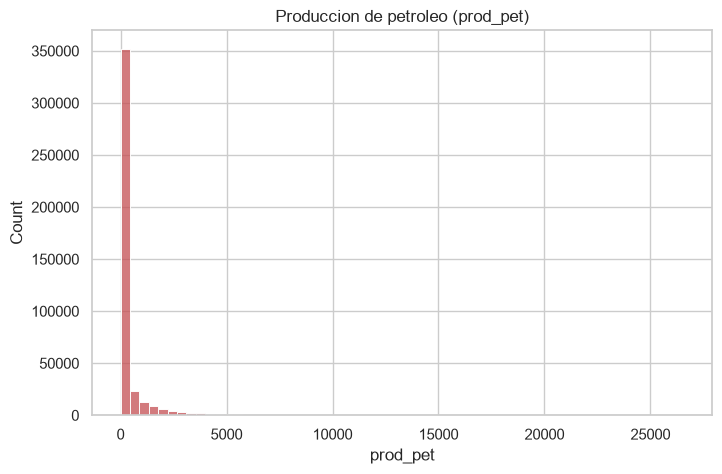

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df["prod_pet"], bins=60, color="#C44E52")
plt.title("Produccion de petroleo (prod_pet)")
plt.show()

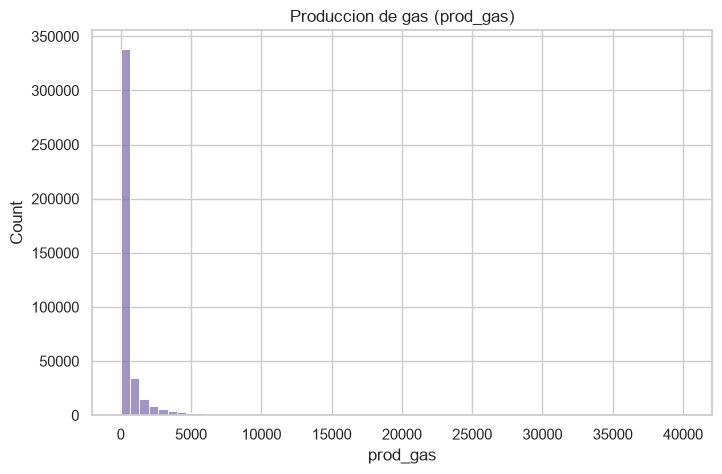

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["prod_gas"], bins=60, color="#8172B2")
plt.title("Produccion de gas (prod_gas)")
plt.show()

In [11]:
# Buscamos las filas con produccion negativa (no deberia existir)
negativos = df[(df["prod_pet"] < 0) | (df["prod_gas"] < 0)]
negativos[["idpozo", "anio", "mes", "prod_pet", "prod_gas"]]

,idpozo,anio,mes,prod_pet,prod_gas
300275,153228,2020,5,1.670,-12.267
300283,153227,2020,5,1.020,-7.519
323445,73804,2008,12,-0.001,0.000


### 2.4 Produccion total por anio (todavia sin limpiar)

Ojo: el anio 2026 va a aparecer mas bajo porque todavia no tiene los 12 meses cargados.
No es que la produccion haya caido de verdad.

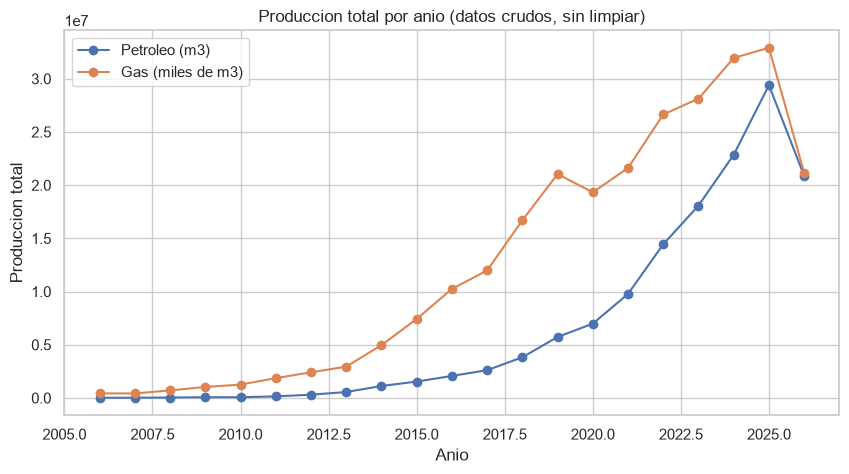

In [12]:
produccion_por_anio = df.groupby("anio")[["prod_pet", "prod_gas"]].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(produccion_por_anio["anio"], produccion_por_anio["prod_pet"], marker="o", label="Petroleo (m3)")
plt.plot(produccion_por_anio["anio"], produccion_por_anio["prod_gas"], marker="o", label="Gas (miles de m3)")
plt.xlabel("Anio")
plt.ylabel("Produccion total")
plt.title("Produccion total por anio (datos crudos, sin limpiar)")
plt.legend()
plt.show()

## Paso 3: Limpiar los datos

Usamos la funcion `limpiar_datos()` de `preprocessor.py`, que hace todo esto en un solo paso:
- Borra las columnas casi vacias (`vida_util`, `observaciones`)
- Rellena los nulos de las columnas de texto con el valor mas comun
- Arregla la profundidad (la fuera de rango la reemplaza por la mediana de la formacion)
- Convierte la produccion negativa en 0
- Marca el anio 2026 como "incompleto"

In [13]:
df_limpio = limpiar_datos(df)

print("Filas y columnas antes:", df.shape)
print("Filas y columnas despues:", df_limpio.shape)
print("Nulos en profundidad despues:", df_limpio["profundidad"].isnull().sum())
print("Produccion negativa despues:", (df_limpio["prod_pet"] < 0).sum() + (df_limpio["prod_gas"] < 0).sum())

Filas y columnas antes: (421046, 40)
Filas y columnas despues: (421046, 39)
Nulos en profundidad despues: 0
Produccion negativa despues: 0


## Paso 4: Confirmar con graficos que la limpieza funciono

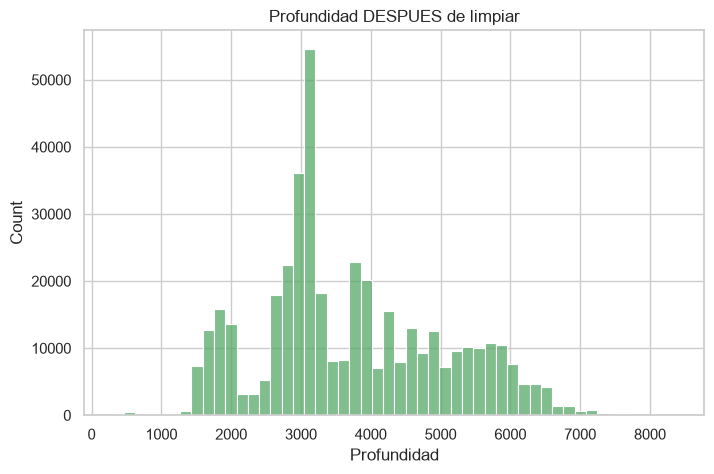

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df_limpio["profundidad"], bins=50, color="#55A868")
plt.title("Profundidad DESPUES de limpiar")
plt.xlabel("Profundidad")
plt.show()

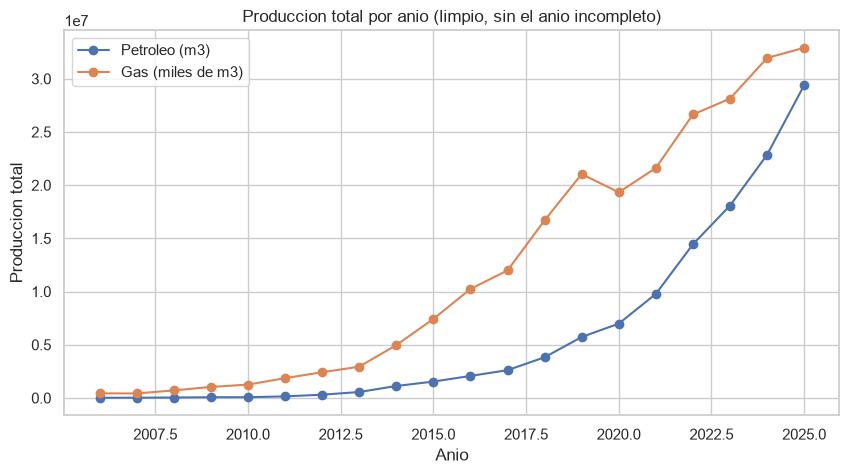

In [15]:
# Ahora recalculamos la produccion por anio, pero sacando el anio incompleto (2026)
solo_anios_completos = df_limpio[df_limpio["anio_completo"]]
produccion_limpia = solo_anios_completos.groupby("anio")[["prod_pet", "prod_gas"]].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(produccion_limpia["anio"], produccion_limpia["prod_pet"], marker="o", label="Petroleo (m3)")
plt.plot(produccion_limpia["anio"], produccion_limpia["prod_gas"], marker="o", label="Gas (miles de m3)")
plt.xlabel("Anio")
plt.ylabel("Produccion total")
plt.title("Produccion total por anio (limpio, sin el anio incompleto)")
plt.legend()
plt.show()

## Conclusiones

- Los nulos de `vida_util` y `observaciones` se resolvieron borrando esas columnas (tenian casi todo vacio).
- La profundidad quedo dentro de un rango normal (entre 1.500 y 7.000 aprox), sin el error de 378.939.
- La produccion negativa (solo 3 filas) quedo en 0.
- Al sacar el anio 2026 (incompleto), la curva de produccion muestra el crecimiento real de Vaca Muerta desde 2006 hasta 2025, sin caidas falsas.

**Proximo paso:** armar `02_feature_engineering.ipynb` para crear variables nuevas (por ejemplo: cuantos meses lleva produciendo cada pozo, o cuanto bajo la produccion mes a mes).